In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [48]:
X,y = make_classification(n_samples=1000, n_features = 3, n_informative=3, n_redundant=0,
                         n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=2)

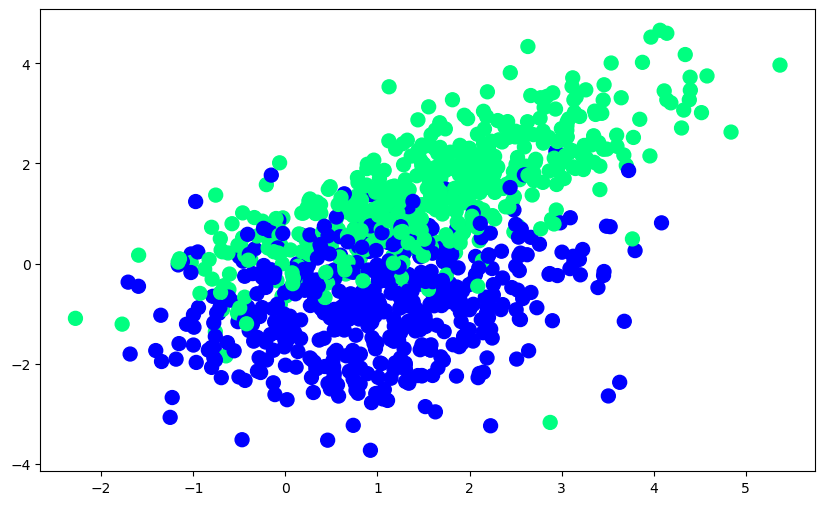

In [49]:
plt.figure(figsize=(10,6))
plt.scatter(
    X[:,0],      # x coordinates → Feature 0
    X[:,1],      # y coordinates → Feature 1
    c=y,         # color → class label
    cmap='winter', # color scheme
    s=100        # point size
)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=13)

In [51]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [52]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 1 1 1
 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 1 0 1 1 0 1 1 0
 0 1 0 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1
 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 1 1 0 1 1 1 0 0
 1 0 1 1 0 1 1 0 1 1 1 0 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0
 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1]


In [53]:
# Confusion Matrix
# sklearn returns:
#
# [[TN, FP],
#  [FN, TP]]

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[88 12]
 [ 4 96]]


In [54]:
# Extract the four values from the confusion matrix
TN, FP, FN, TP = cm.ravel()
print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)


True Negative (TN): 88
False Positive (FP): 12
False Negative (FN): 4
True Positive (TP): 96


In [63]:
# Accuracy Score
# Accuracy = (TP + TN) / (TP + TN + FP + FN)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score :{accuracy} %' )

Accuracy Score :0.92 %


In [64]:
# Manual calculation using confusion matrix values
accuracy_manual = (
    (TP + TN) /
    (TP + TN + FP + FN)
)

print("Accuracy (Manual):", accuracy_manual)

Accuracy (Manual): 0.92


In [69]:
# Precision Score
# Precision = TP / (TP + FP)  - "Out of everything predicted as Positive, how many were actually Positive?"


precision  = precision_score(y_test, y_pred)
print('Precision Score: {:.2f}'.format(precision))

# Manual calculation
precision_manual = TP / (TP + FP)

print("Precision (Manual):{:.2f}".format(precision_manual))

Precision Score: 0.89
Precision (Manual):0.89


In [74]:
# Recall
# Recall = TP / (TP + FN) - # "Out of all actual Positive cases,how many did the model correctly find?"

recall  = recall_score(y_test,y_pred)
print('Recall Score :{:.2f}'.format(recall))

recall_manual = TP / (TP + FN)
print('Recall Score : {:.2f}'.format(recall_manual))

Recall Score :0.96
Recall Score : 0.96


In [108]:
# F1 Score
# F1 = 2 * ((precision * recall)/(precision + Recall))
f1 = f1_score(y_test,y_pred)
print('F1 Score: {:.2f}'.format(f1))

# Manual Calculation
f1_manual =  (
    2 * (precision * recall) / (precision + recall)
)
print('F1 Manual : {:.2f}'.format(f1_manual))

F1 Score: 0.92
F1 Manual : 0.92


In [79]:
print("CLASSIFICATION METRICS")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

CLASSIFICATION METRICS
Accuracy  : 0.9200
Precision : 0.8889
Recall    : 0.9600
F1 Score  : 0.9231


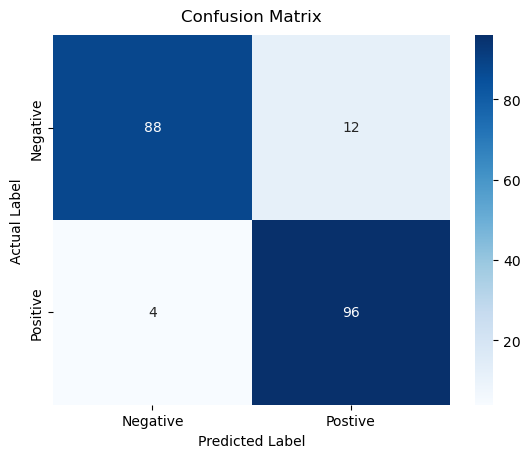

In [84]:
# Visualize the Confusion Matrix

sns.heatmap(cm, annot=True, fmt = 'd', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix", pad=10)

plt.show()

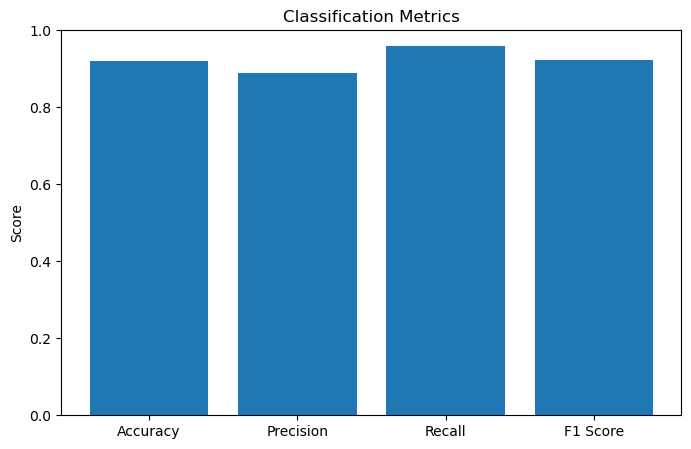

In [85]:
# Visualize the metrics

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("Classification Metrics")

plt.show()

## ROC Curve

In [94]:
from sklearn.metrics import roc_curve, roc_auc_score

In [99]:
y_prob = model.predict_proba(X_test)[:,1]
np.set_printoptions(suppress=True)

print(y_prob[:10])

[0.92797156 0.00093449 0.96220391 0.93601658 0.00052731 0.92605576
 0.00563629 0.97300554 0.3260313  0.90730972]


In [103]:
# Calculate FPR, TPR and thresholds
# ROC Curve

# True Positive Rate (TPR): TPR = TP / (TP + FN)

# False Positive Rate (FPR): FPR = FP / (FP + TN)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print("False Positive Rate:")
print(fpr)

print("\nTrue Positive Rate:")
print(tpr)

print("\nThresholds:")
print(thresholds)

False Positive Rate:
[0.   0.   0.   0.01 0.01 0.03 0.03 0.04 0.04 0.05 0.05 0.06 0.06 0.08
 0.08 0.09 0.09 0.1  0.1  0.12 0.12 0.19 0.19 0.2  0.2  0.27 0.27 0.44
 0.44 1.  ]

True Positive Rate:
[0.   0.01 0.54 0.54 0.6  0.6  0.62 0.62 0.72 0.72 0.83 0.83 0.84 0.84
 0.88 0.88 0.92 0.92 0.94 0.94 0.96 0.96 0.97 0.97 0.98 0.98 0.99 0.99
 1.   1.  ]

Thresholds:
[       inf 0.99764722 0.92687623 0.92605576 0.90730972 0.90393204
 0.89770786 0.89648313 0.87990107 0.876543   0.75831661 0.73196976
 0.73111752 0.72699821 0.65535073 0.637587   0.59375768 0.58067681
 0.54603941 0.51582037 0.51005148 0.35171719 0.34447545 0.34027193
 0.3260313  0.21134032 0.20809532 0.07079156 0.06871081 0.00004551]


## Calculate ROC-AUC

In [104]:
# ROC-AUC
# AUC = Area Under the ROC Curve

# ROC-AUC measures the area under the True Positive Rate vs False Positive Rate curve. 

# AUC = 1.0 → Perfect classifier
# AUC = 0.5 → Random classifier

# Higher AUC generally means better ability to distinguish between the two classes.

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9665


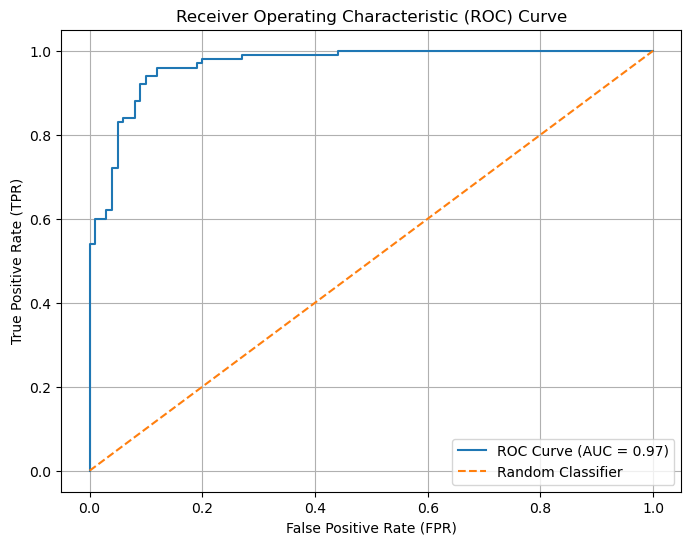

In [107]:
# Plot ROC Curve

plt.figure(figsize=(8, 6))

# ROC Curve
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")

# Random Classifier
# For a random classifier:
# TPR = FPR
# Therefore, the random classifier is represented
# by the diagonal line y = x.

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.legend()
plt.grid()
plt.show()

In [109]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)

Optimal threshold is: 0.5460394144512669
